# AI-Driven Student Performance Prediction System
Predicts a student's final grade and pass/fail outcome using machine learning,
based on demographic, family, and lifestyle factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
sns.set_style("whitegrid")

## 1. Load Dataset

In [2]:
df = pd.read_csv("../data/student_performance.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,19,U,LE3,T,0,1,3,2,...,5,2,2,1,2,3,9,10,9,0
1,MS,F,18,U,GT3,T,1,1,4,3,...,1,2,2,4,5,6,11,11,11,1
2,MS,F,19,U,GT3,T,0,2,3,3,...,2,2,3,2,2,8,13,13,12,1
3,GP,M,16,R,GT3,A,3,2,4,3,...,1,1,2,1,2,2,15,15,15,1
4,GP,F,18,U,GT3,T,4,1,1,3,...,4,3,4,5,3,8,15,13,15,1


In [3]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.00000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,17.046667,1.981111,1.962222,2.482222,2.455556,0.406667,3.050000,2.866667,2.997778,2.97000,2.943333,3.110000,4.182222,13.414444,13.444444,13.423333,0.883333
std,1.410291,1.417623,1.405818,1.120501,1.119760,0.791473,1.436358,1.417356,1.414212,1.37521,1.418968,1.432233,2.096694,3.265829,3.261366,3.293522,0.321201
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,0.000000,2.000000,2.000000,2.000000,0.000000
25%,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,11.000000,11.000000,11.000000,1.000000
50%,17.000000,2.000000,2.000000,3.000000,2.000000,0.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,4.000000,13.000000,14.000000,13.000000,1.000000
75%,18.000000,3.000000,3.000000,3.000000,3.000000,0.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,6.000000,16.000000,16.000000,16.000000,1.000000
max,19.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,12.000000,20.000000,20.000000,20.000000,1.000000


## 2. Exploratory Data Analysis

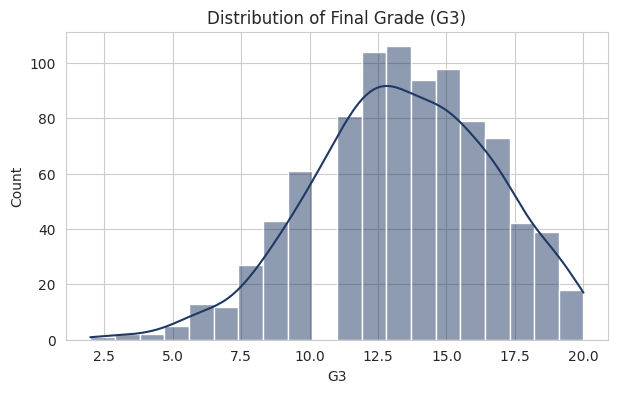

In [4]:
plt.figure(figsize=(7,4))
sns.histplot(df["G3"], bins=20, kde=True, color="#1F3864")
plt.title("Distribution of Final Grade (G3)")
plt.show()

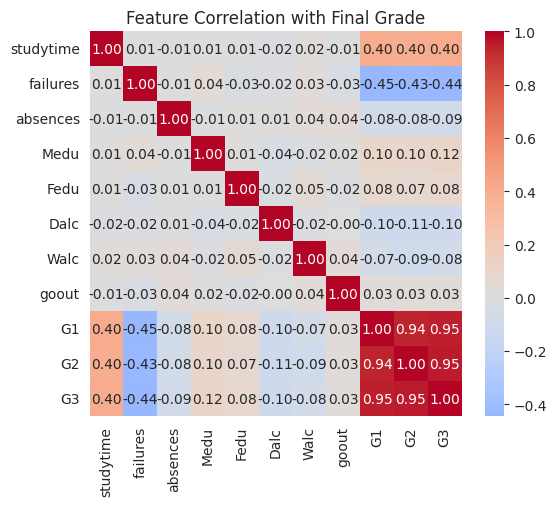

In [5]:
plt.figure(figsize=(6,5))
corr_cols = ["studytime","failures","absences","Medu","Fedu","Dalc","Walc","goout","G1","G2","G3"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation with Final Grade")
plt.show()

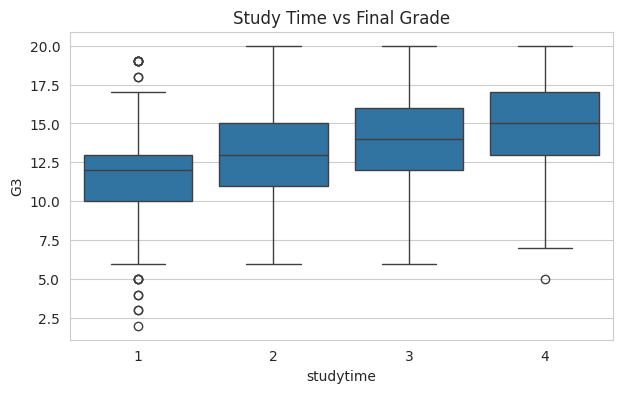

In [6]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="studytime", y="G3")
plt.title("Study Time vs Final Grade")
plt.show()

**Observation:** Final grade correlates strongly with prior period grades (G1, G2),
positively with study time, and negatively with number of past failures.

## 3. Preprocessing

In [7]:
data = df.copy()
cat_cols = data.select_dtypes(include="object").columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

feature_cols = [c for c in data.columns if c not in ["G3","pass"]]
X = data[feature_cols]
y_reg = data["G3"]
y_clf = data["pass"]

X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

/tmp/ipykernel_608/3073531183.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include="object").columns.tolist()


## 4. Regression: Predicting Final Grade (G3)

In [8]:
lr = LinearRegression().fit(X_train_s, yreg_train)
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(X_train, yreg_train)

lr_pred = lr.predict(X_test_s)
rf_pred = rf_reg.predict(X_test)

for name, pred in [("Linear Regression", lr_pred), ("Random Forest", rf_pred)]:
    rmse = np.sqrt(mean_squared_error(yreg_test, pred))
    mae = mean_absolute_error(yreg_test, pred)
    r2 = r2_score(yreg_test, pred)
    print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

Linear Regression: RMSE=0.864, MAE=0.680, R2=0.932
Random Forest: RMSE=1.003, MAE=0.794, R2=0.908


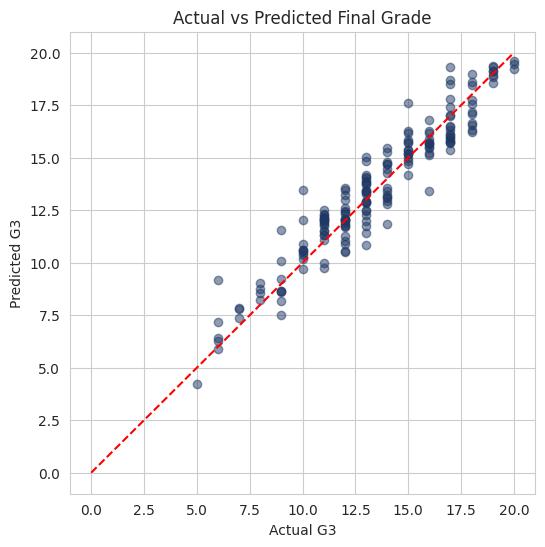

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(yreg_test, rf_pred, alpha=0.5, color="#1F3864")
plt.plot([0,20],[0,20],"r--")
plt.xlabel("Actual G3"); plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grade")
plt.show()

## 5. Classification: Predicting Pass / Fail
A student is considered to "pass" if G3 >= 10 (out of 20).

In [10]:
log_reg = LogisticRegression(max_iter=1000).fit(X_train_s, yclf_train)
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42).fit(X_train, yclf_train)

log_pred = log_reg.predict(X_test_s)
rf_clf_pred = rf_clf.predict(X_test)

for name, pred in [("Logistic Regression", log_pred), ("Random Forest", rf_clf_pred)]:
    acc = accuracy_score(yclf_test, pred)
    prec = precision_score(yclf_test, pred, zero_division=0)
    rec = recall_score(yclf_test, pred, zero_division=0)
    f1 = f1_score(yclf_test, pred, zero_division=0)
    print(f"{name}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

Logistic Regression: Accuracy=0.961, Precision=0.963, Recall=0.994, F1=0.978
Random Forest: Accuracy=0.983, Precision=0.981, Recall=1.000, F1=0.991


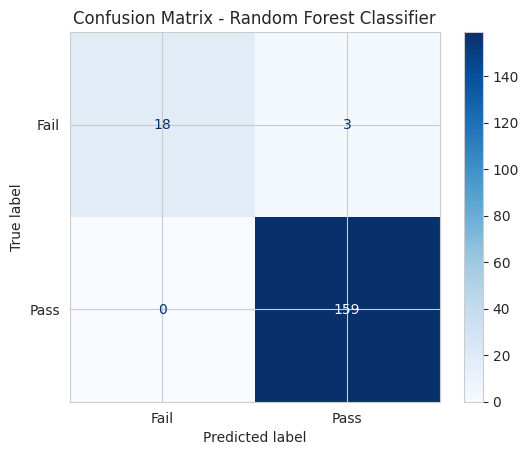

In [11]:
cm = confusion_matrix(yclf_test, rf_clf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail","Pass"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

## 6. Feature Importance

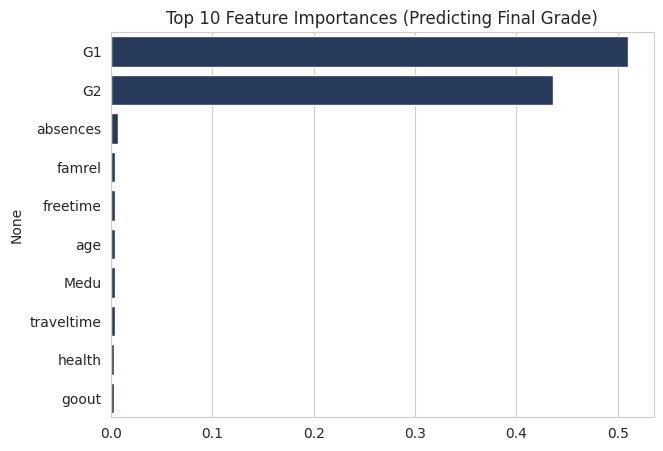

In [12]:
importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, color="#1F3864")
plt.title("Top 10 Feature Importances (Predicting Final Grade)")
plt.show()

## 7. Conclusion
- Random Forest Classifier achieved the best pass/fail prediction performance (F1 ~0.99).
- Linear Regression performed best for exact grade prediction (R2 ~0.93), showing the
  underlying relationships are largely linear once G1/G2 are included.
- Prior grades, number of failures, and study time are the strongest predictors of
  final academic performance — consistent with educational research.
- This model could support early-warning systems for at-risk students in real institutions.